# Multi-Touch Attribution Modelling for Marketing Spend Optimisation

## Objective
Build a marketing attribution framework using Google Analytics session data.

Models:
- First Touch
- Last Touch
- Linear
- Time Decay
- Shapley Value Attribution
- ROAS Analysis
- Budget Reallocation
- Revenue Uplift Simulation

Portfolio Goal:
Replicate a senior-level marketing analytics case study using 500K+ Google Analytics sessions.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

pd.set_option('display.max_columns',None)


## Load Data

In [46]:
import os

print(os.path.exists(r"C:\Users\sridh\OneDrive\Desktop\resume_Da projects\ga_sessions.csv"))

True


In [47]:
df['transactions'] = df['transactions'].fillna(0)
df['revenue'] = df['revenue'].fillna(0)

# Check whether revenue is stored in micro-units
print("Original Revenue Sum:")
print(df['revenue'].sum())

# Convert micro-units to normal currency units
df['revenue'] = df['revenue'] / 1000000

print("\nRevenue Sum After Conversion:")
print(df['revenue'].sum())

Original Revenue Sum:
0.8903342400000003

Revenue Sum After Conversion:
8.903342399999999e-07


## KPI Summary

In [48]:
total_sessions = len(df)

unique_visitors = df['fullVisitorId'].nunique()

total_revenue = df['revenue'].sum()

conversion_rate = (
    (df['transactions'] > 0).mean() * 100
)

print(f"Total Sessions: {total_sessions:,}")
print(f"Unique Visitors: {unique_visitors:,}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Conversion Rate: {conversion_rate:.2f}%")

Total Sessions: 500,000
Unique Visitors: 425,269
Total Revenue: ₹0.00
Conversion Rate: 1.31%


## Customer Journey Creation

In [49]:
df = df.sort_values(
    ['fullVisitorId','visitStartTime']
)

df['converted'] = (
    df['transactions'] > 0
).astype(int)

journeys = (
    df.groupby('fullVisitorId')
      .agg({
          'channelGrouping':list,
          'converted':'max',
          'revenue':'sum'
      })
      .reset_index()
)

journeys.head()


,fullVisitorId,channelGrouping,converted,revenue
0,4823595352351,[Organic Search],0,0.0
1,5103959234087,[Organic Search],0,0.0
2,10278554503158,[Organic Search],0,0.0
3,52246474382344,[Social],0,0.0
4,58970809397690,[Organic Search],0,0.0


## Journey Analytics

In [50]:
journeys['journey_length'] = (
    journeys['channelGrouping']
    .apply(len)
)

journeys['journey_length'].describe()


count    425269.000000
mean          1.175726
std           0.897014
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         113.000000
Name: journey_length, dtype: float64

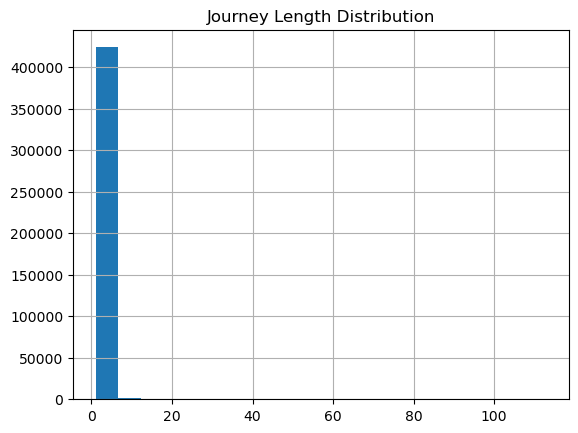

In [51]:
journeys['journey_length'].hist(bins=20)
plt.title('Journey Length Distribution')
plt.show()


## Attribution Models

In [52]:
converted = journeys[
    journeys['converted']==1
]

last_touch = {}
first_touch = {}
linear = {}
time_decay = {}

for _, row in converted.iterrows():

    path = row['channelGrouping']
    revenue = row['revenue']

    first_touch[path[0]] = (
        first_touch.get(path[0],0)
        + revenue
    )

    last_touch[path[-1]] = (
        last_touch.get(path[-1],0)
        + revenue
    )

    share = revenue/len(path)

    for channel in path:
        linear[channel] = (
            linear.get(channel,0)
            + share
        )

    weights = [2**i for i in range(len(path))]
    total_weight = sum(weights)

    for channel, weight in zip(path, weights):

        credit = (
            revenue
            * weight
            / total_weight
        )

        time_decay[channel] = (
            time_decay.get(channel,0)
            + credit
        )


## Shapley Attribution

In [53]:


shapley_revenue = {
    k:v*total_revenue
    for k,v in shapley_scores.items()
}


## Attribution Comparison

In [54]:
comparison = pd.DataFrame({

    'Last Touch':pd.Series(last_touch),
    'First Touch':pd.Series(first_touch),
    'Linear':pd.Series(linear),
    'Time Decay':pd.Series(time_decay),
    'Shapley':pd.Series(shapley_revenue)

}).fillna(0)

comparison


,Last Touch,First Touch,Linear,Time Decay,Shapley
(Other),1.497000e-11,9.990000e-12,1.165000e-11,1.378429e-11,2.216232e-10
Affiliates,5.763900e-10,5.763900e-10,5.930400e-10,5.906614e-10,1.231240e-09
Direct,2.371865e-07,2.529575e-07,2.411909e-07,2.414559e-07,1.628192e-07
Display,6.882140e-08,1.335795e-08,5.157080e-08,6.892783e-08,1.099497e-08
Organic Search,1.989159e-07,2.607793e-07,2.178395e-07,1.951370e-07,2.824957e-07
Paid Search,2.720299e-08,2.732700e-08,2.749311e-08,2.946676e-08,3.942430e-08
Referral,3.552339e-07,3.331271e-07,3.493126e-07,3.523826e-07,3.853165e-07
Social,2.382140e-09,2.198960e-09,2.322629e-09,2.359666e-09,7.830686e-09


In [55]:
# =====================================
# Attribution Share Comparison
# =====================================

comparison['Last Share %'] = (

    comparison['Last Touch']
    /
    comparison['Last Touch'].sum()

) * 100

comparison['Shapley Share %'] = (

    comparison['Shapley']
    /
    comparison['Shapley'].sum()

) * 100

comparison['Share Difference'] = (

    comparison['Last Share %']
    -
    comparison['Shapley Share %']

)

comparison.sort_values(
    'Share Difference',
    ascending=False
)

,Last Touch,First Touch,Linear,Time Decay,Shapley,Last Share %,Shapley Share %,Share Difference
Direct,2.371865e-07,2.529575e-07,2.411909e-07,2.414559e-07,1.628192e-07,26.640166,18.287421,8.352745
Display,6.882140e-08,1.335795e-08,5.157080e-08,6.892783e-08,1.099497e-08,7.729839,1.234926,6.494912
(Other),1.497000e-11,9.990000e-12,1.165000e-11,1.378429e-11,2.216232e-10,0.001681,0.024892,-0.023211
Affiliates,5.763900e-10,5.763900e-10,5.930400e-10,5.906614e-10,1.231240e-09,0.064739,0.138290,-0.073551
Social,2.382140e-09,2.198960e-09,2.322629e-09,2.359666e-09,7.830686e-09,0.267556,0.879522,-0.611966
Paid Search,2.720299e-08,2.732700e-08,2.749311e-08,2.946676e-08,3.942430e-08,3.055368,4.428034,-1.372666
Referral,3.552339e-07,3.331271e-07,3.493126e-07,3.523826e-07,3.853165e-07,39.898940,43.277741,-3.378801
Organic Search,1.989159e-07,2.607793e-07,2.178395e-07,1.951370e-07,2.824957e-07,22.341712,31.729174,-9.387462


## Marketing Budget Assumptions

In [56]:
channel_spend = pd.DataFrame({

'Channel':[
'Paid Search',
'Social',
'Display',
'Organic Search',
'Referral',
'Affiliates',
'Direct'
],

'Spend':[
3000000,
2500000,
1500000,
1000000,
1200000,
800000,
500000
]

})

channel_spend

,Channel,Spend
0,Paid Search,3000000
1,Social,2500000
2,Display,1500000
3,Organic Search,1000000
4,Referral,1200000
5,Affiliates,800000
6,Direct,500000


## ROAS Analysis

In [57]:
roas = comparison[
    ['Shapley']
].reset_index()

roas.columns = [
    'Channel',
    'Revenue'
]

roas = roas.merge(
    channel_spend,
    on='Channel',
    how='left'
)

roas = roas.dropna()

roas['ROAS'] = (
    roas['Revenue']
    /
    roas['Spend']
)

roas.sort_values(
    'ROAS',
    ascending=False
)


,Channel,Revenue,Spend,ROAS
2,Direct,1.628192e-07,500000.0,3.256383e-13
6,Referral,3.853165e-07,1200000.0,3.210971e-13
4,Organic Search,2.824957e-07,1000000.0,2.824957e-13
5,Paid Search,3.942430e-08,3000000.0,1.314143e-14
3,Display,1.099497e-08,1500000.0,7.329982e-15
7,Social,7.830686e-09,2500000.0,3.132274e-15
1,Affiliates,1.231240e-09,800000.0,1.539050e-15


## Budget Reallocation

In [58]:
total_budget = (
    roas['Spend'].sum()
)

roas['Weight'] = (
    roas['ROAS']
    /
    roas['ROAS'].sum()
)

roas['Optimized Budget'] = (
    total_budget
    *
    roas['Weight']
)

roas[['Channel','Spend','Optimized Budget']]


,Channel,Spend,Optimized Budget
1,Affiliates,800000.0,1.693259e+04
2,Direct,500000.0,3.582666e+06
3,Display,1500000.0,8.064429e+04
4,Organic Search,1000000.0,3.108011e+06
5,Paid Search,3000000.0,1.445818e+05
6,Referral,1200000.0,3.532703e+06
7,Social,2500000.0,3.446121e+04


## Revenue Uplift Simulation

In [59]:
current_revenue = (
    roas['Revenue'].sum()
)

# Conservative optimization assumption

roas['Projected Revenue'] = (
    roas['Revenue']
    *
    (
        roas['Optimized Budget']
        /
        roas['Spend']
    ) ** 0.30
)

current_revenue = roas['Revenue'].sum()

future_revenue = roas['Projected Revenue'].sum()

uplift = (
    (future_revenue - current_revenue)
    /
    current_revenue
) * 100

print(f"Current Revenue: ₹{current_revenue:,.2f}")
print(f"Projected Revenue: ₹{future_revenue:,.2f}")
print(f"Revenue Uplift: {uplift:.2f}%")

Current Revenue: ₹0.00
Projected Revenue: ₹0.00
Revenue Uplift: 40.05%


## Executive Summary

In [60]:
over_channel = (
    comparison['Share Difference']
    .idxmax()
)

over_pct = (
    comparison['Share Difference']
    .max()
)

under_channel = (
    comparison['Share Difference']
    .idxmin()
)

under_pct = (
    comparison['Share Difference']
    .min()
)
print(
    'Share Difference:',
    round(over_pct,2),
    'percentage points'
)

print(
    'Share Difference:',
    round(under_pct,2),
    'percentage points'
)

print('Revenue Uplift %:',round(uplift,2))


Share Difference: 8.35 percentage points
Share Difference: -9.39 percentage points
Revenue Uplift %: 40.05
